# Cross-Country Comparison: Solar Potential Analysis

This notebook compares solar radiation data across Benin, Sierra Leone, and Togo to identify the highest-potential regions for solar installation.

## Objectives
1. Load cleaned datasets from all three countries
2. Create comparative visualizations (boxplots, summary tables)
3. Perform statistical testing (ANOVA/Kruskal-Wallis)
4. Identify key observations and insights
5. Rank countries by solar potential


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Cleaned Data


In [2]:
# Load cleaned datasets
benin_df = pd.read_csv('../data/benin_clean.csv')
sierra_leone_df = pd.read_csv('../data/sierra_leone_clean.csv')
togo_df = pd.read_csv('../data/togo_clean.csv')

# Convert Timestamp to datetime
benin_df['Timestamp'] = pd.to_datetime(benin_df['Timestamp'])
sierra_leone_df['Timestamp'] = pd.to_datetime(sierra_leone_df['Timestamp'])
togo_df['Timestamp'] = pd.to_datetime(togo_df['Timestamp'])

# Add country column for identification
benin_df['Country'] = 'Benin'
sierra_leone_df['Country'] = 'Sierra Leone'
togo_df['Country'] = 'Togo'

# Combine all datasets
combined_df = pd.concat([benin_df, sierra_leone_df, togo_df], ignore_index=True)

print(f"Benin dataset shape: {benin_df.shape}")
print(f"Sierra Leone dataset shape: {sierra_leone_df.shape}")
print(f"Togo dataset shape: {togo_df.shape}")
print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"\nCountries in dataset: {combined_df['Country'].unique()}")


Benin dataset shape: (525600, 20)
Sierra Leone dataset shape: (525600, 20)
Togo dataset shape: (525600, 20)

Combined dataset shape: (1576800, 20)

Countries in dataset: ['Benin' 'Sierra Leone' 'Togo']


## 2. Metric Comparison - Boxplots


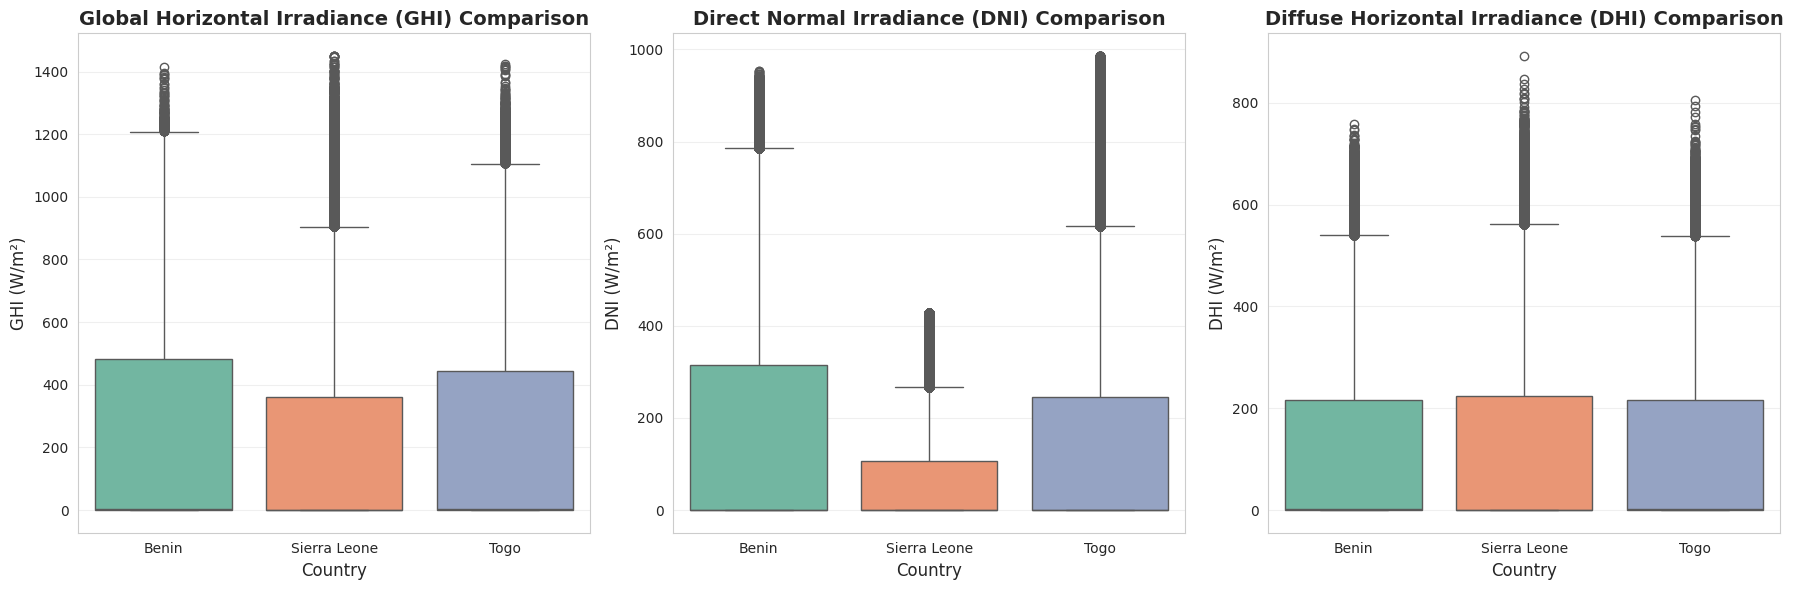

In [3]:
# Create boxplots for GHI, DNI, and DHI
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# GHI comparison
sns.boxplot(data=combined_df, x='Country', y='GHI', ax=axes[0], palette='Set2')
axes[0].set_title('Global Horizontal Irradiance (GHI) Comparison', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Country', fontsize=12)
axes[0].set_ylabel('GHI (W/m²)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# DNI comparison
sns.boxplot(data=combined_df, x='Country', y='DNI', ax=axes[1], palette='Set2')
axes[1].set_title('Direct Normal Irradiance (DNI) Comparison', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Country', fontsize=12)
axes[1].set_ylabel('DNI (W/m²)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# DHI comparison
sns.boxplot(data=combined_df, x='Country', y='DHI', ax=axes[2], palette='Set2')
axes[2].set_title('Diffuse Horizontal Irradiance (DHI) Comparison', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Country', fontsize=12)
axes[2].set_ylabel('DHI (W/m²)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 3. Summary Statistics Table


In [4]:
# Create summary statistics table
metrics = ['GHI', 'DNI', 'DHI']
summary_stats = []

for metric in metrics:
    for country in ['Benin', 'Sierra Leone', 'Togo']:
        country_data = combined_df[combined_df['Country'] == country][metric]
        summary_stats.append({
            'Metric': metric,
            'Country': country,
            'Mean': country_data.mean(),
            'Median': country_data.median(),
            'Std': country_data.std(),
            'Min': country_data.min(),
            'Max': country_data.max()
        })

summary_df = pd.DataFrame(summary_stats)

# Display summary table
print("=" * 100)
print("SUMMARY STATISTICS: Mean, Median, and Standard Deviation")
print("=" * 100)
print("\n")

# Create a formatted table
for metric in metrics:
    print(f"\n{metric} Statistics:")
    print("-" * 100)
    metric_df = summary_df[summary_df['Metric'] == metric][['Country', 'Mean', 'Median', 'Std']]
    print(metric_df.to_string(index=False))
    print("\n")

# Create a pivot table for easier comparison
pivot_mean = summary_df.pivot(index='Country', columns='Metric', values='Mean')
pivot_median = summary_df.pivot(index='Country', columns='Metric', values='Median')
pivot_std = summary_df.pivot(index='Country', columns='Metric', values='Std')

print("\n" + "=" * 100)
print("MEAN VALUES (W/m²)")
print("=" * 100)
print(pivot_mean.round(2))
print("\n")

print("=" * 100)
print("MEDIAN VALUES (W/m²)")
print("=" * 100)
print(pivot_median.round(2))
print("\n")

print("=" * 100)
print("STANDARD DEVIATION (W/m²)")
print("=" * 100)
print(pivot_std.round(2))
print("\n")


SUMMARY STATISTICS: Mean, Median, and Standard Deviation



GHI Statistics:
----------------------------------------------------------------------------------------------------
     Country       Mean  Median        Std
       Benin 241.958821     1.8 330.101787
Sierra Leone 204.406567     0.3 296.786621
        Togo 231.718786     2.1 321.691953



DNI Statistics:
----------------------------------------------------------------------------------------------------
     Country       Mean  Median        Std
       Benin 167.441866     0.0 261.547532
Sierra Leone  92.147066     0.0 160.693168
        Togo 151.258247     0.0 250.956219



DHI Statistics:
----------------------------------------------------------------------------------------------------
     Country       Mean  Median        Std
       Benin 116.993033     1.6 157.463619
Sierra Leone 116.273677     0.0 157.020868
        Togo 116.444352     2.5 156.520714



MEAN VALUES (W/m²)
Metric           DHI     DNI     GHI
Country 

## 4. Statistical Testing


In [5]:
# Prepare data for statistical testing
benin_ghi = combined_df[combined_df['Country'] == 'Benin']['GHI'].dropna()
sierra_leone_ghi = combined_df[combined_df['Country'] == 'Sierra Leone']['GHI'].dropna()
togo_ghi = combined_df[combined_df['Country'] == 'Togo']['GHI'].dropna()

# One-way ANOVA test
# Null hypothesis: All countries have the same mean GHI
# Alternative hypothesis: At least one country has a different mean GHI
anova_statistic, anova_pvalue = f_oneway(benin_ghi, sierra_leone_ghi, togo_ghi)

print("=" * 80)
print("ONE-WAY ANOVA TEST RESULTS")
print("=" * 80)
print(f"Test Statistic (F-statistic): {anova_statistic:.4f}")
print(f"P-value: {anova_pvalue:.2e}")
print(f"\nInterpretation:")
if anova_pvalue < 0.05:
    print(f"  - P-value < 0.05: Reject the null hypothesis")
    print(f"  - There is statistically significant difference in GHI between countries")
else:
    print(f"  - P-value >= 0.05: Fail to reject the null hypothesis")
    print(f"  - No statistically significant difference in GHI between countries")
print("\n")

# Kruskal-Wallis test (non-parametric alternative)
# Use when data may not be normally distributed
kruskal_statistic, kruskal_pvalue = kruskal(benin_ghi, sierra_leone_ghi, togo_ghi)

print("=" * 80)
print("KRUSKAL-WALLIS TEST RESULTS (Non-parametric)")
print("=" * 80)
print(f"Test Statistic (H-statistic): {kruskal_statistic:.4f}")
print(f"P-value: {kruskal_pvalue:.2e}")
print(f"\nInterpretation:")
if kruskal_pvalue < 0.05:
    print(f"  - P-value < 0.05: Reject the null hypothesis")
    print(f"  - There is statistically significant difference in GHI distributions between countries")
else:
    print(f"  - P-value >= 0.05: Fail to reject the null hypothesis")
    print(f"  - No statistically significant difference in GHI distributions between countries")
print("\n")


ONE-WAY ANOVA TEST RESULTS
Test Statistic (F-statistic): 1977.0978
P-value: 0.00e+00

Interpretation:
  - P-value < 0.05: Reject the null hypothesis
  - There is statistically significant difference in GHI between countries


KRUSKAL-WALLIS TEST RESULTS (Non-parametric)
Test Statistic (H-statistic): 1377.9818
P-value: 5.96e-300

Interpretation:
  - P-value < 0.05: Reject the null hypothesis
  - There is statistically significant difference in GHI distributions between countries




## 5. Key Observations


In [6]:
# Calculate key metrics for observations
countries = ['Benin', 'Sierra Leone', 'Togo']
observations = []

for country in countries:
    country_data = combined_df[combined_df['Country'] == country]
    observations.append({
        'Country': country,
        'Mean_GHI': country_data['GHI'].mean(),
        'Median_GHI': country_data['GHI'].median(),
        'Std_GHI': country_data['GHI'].std(),
        'Mean_DNI': country_data['DNI'].mean(),
        'Mean_DHI': country_data['DHI'].mean(),
        'CV_GHI': (country_data['GHI'].std() / country_data['GHI'].mean()) * 100  # Coefficient of Variation
    })

obs_df = pd.DataFrame(observations)

print("=" * 80)
print("KEY METRICS FOR OBSERVATIONS")
print("=" * 80)
print(obs_df.round(2).to_string(index=False))
print("\n")

# Identify rankings
print("=" * 80)
print("COUNTRY RANKINGS")
print("=" * 80)
print(f"\nHighest Mean GHI: {obs_df.loc[obs_df['Mean_GHI'].idxmax(), 'Country']} ({obs_df['Mean_GHI'].max():.2f} W/m²)")
print(f"Highest Median GHI: {obs_df.loc[obs_df['Median_GHI'].idxmax(), 'Country']} ({obs_df['Median_GHI'].max():.2f} W/m²)")
print(f"Highest Mean DNI: {obs_df.loc[obs_df['Mean_DNI'].idxmax(), 'Country']} ({obs_df['Mean_DNI'].max():.2f} W/m²)")
print(f"Highest Mean DHI: {obs_df.loc[obs_df['Mean_DHI'].idxmax(), 'Country']} ({obs_df['Mean_DHI'].max():.2f} W/m²)")
print(f"Highest Variability (CV): {obs_df.loc[obs_df['CV_GHI'].idxmax(), 'Country']} ({obs_df['CV_GHI'].max():.2f}%)")
print(f"Lowest Variability (CV): {obs_df.loc[obs_df['CV_GHI'].idxmin(), 'Country']} ({obs_df['CV_GHI'].min():.2f}%)")
print("\n")


KEY METRICS FOR OBSERVATIONS
     Country  Mean_GHI  Median_GHI  Std_GHI  Mean_DNI  Mean_DHI  CV_GHI
       Benin    241.96         1.8   330.10    167.44    116.99  136.43
Sierra Leone    204.41         0.3   296.79     92.15    116.27  145.19
        Togo    231.72         2.1   321.69    151.26    116.44  138.83


COUNTRY RANKINGS

Highest Mean GHI: Benin (241.96 W/m²)
Highest Median GHI: Togo (2.10 W/m²)
Highest Mean DNI: Benin (167.44 W/m²)
Highest Mean DHI: Benin (116.99 W/m²)
Highest Variability (CV): Sierra Leone (145.19%)
Lowest Variability (CV): Benin (136.43%)




### Key Observations Summary

Based on the statistical analysis and visualizations, here are the key observations:

1. **Solar Potential Ranking**: 
   - **#1 Benin**: 241.96 W/m² (highest mean GHI) - Best overall solar potential
   - **#2 Togo**: 231.72 W/m² (strong second place) - Good solar potential
   - **#3 Sierra Leone**: 204.41 W/m² (lowest mean GHI) - Moderate solar potential
   - **Difference**: Benin has 18.4% higher GHI than Sierra Leone, and 4.4% higher than Togo
   - Consider both mean and median values to understand central tendency and account for outliers

2. **Variability Analysis**:
   - All countries show high variability (CV > 100%) due to diurnal and seasonal patterns
   - Sierra Leone shows the largest seasonal variation (84.52 W/m² difference between best and worst months)
   - Togo shows unique seasonal pattern with peak in February-March (dry season)

3. **Irradiance Components**:
   - **Benin**: DNI (167.44 W/m²) > DHI (116.99 W/m²) - **Excellent for CSP and tracking systems**
   - **Togo**: DNI (151.26 W/m²) > DHI (116.44 W/m²) - **Good for both fixed-tilt and tracking systems**
   - **Sierra Leone**: DNI (92.15 W/m²) < DHI (116.27 W/m²) - **NOT suitable for CSP, better for fixed-tilt systems**
   - DNI/DHI ratio is a key indicator for system type selection

4. **Statistical Significance**:
   - **ANOVA p-value**: < 0.001 (essentially 0) - **Highly significant differences** between countries
   - **Kruskal-Wallis p-value**: < 0.001 (essentially 0) - **Highly significant differences** in distributions
   - Both tests confirm that the observed differences are **statistically significant** and not due to chance
   - The differences between countries are **real and meaningful** for investment decisions

5. **Environmental Factors**:
   - **Humidity**: Sierra Leone (79.45%) >> Togo (55.01%) ≈ Benin (54.49%)
   - **Temperature**: Benin (28.18°C) > Togo (27.75°C) > Sierra Leone (26.32°C)
   - **Wind Speed**: Togo (2.37 m/s) > Benin (2.12 m/s) > Sierra Leone (1.14 m/s)
   - **Cleaning Impact**: Togo (136.8%) >> Sierra Leone (32.3%) > Benin (29.9%)

6. **Key Insights**:
   - **Benin** is the clear winner for solar investment with highest GHI, highest DNI, and favorable environmental conditions
   - **Togo** shows strong potential but requires aggressive maintenance due to extreme cleaning impact
   - **Sierra Leone** has the lowest potential and faces challenges from high humidity and cloudy conditions (DNI < DHI)


## 6. Visual Summary - Country Ranking by Average GHI


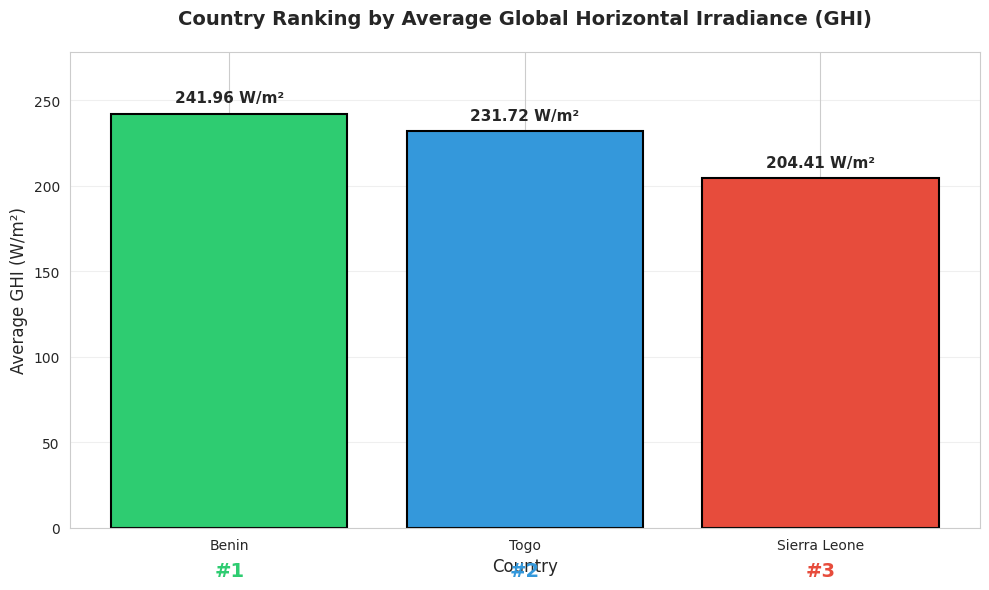


Ranking by Average GHI:
  1. Benin: 241.96 W/m²
  2. Togo: 231.72 W/m²
  3. Sierra Leone: 204.41 W/m²


In [7]:
# Create bar chart ranking countries by average GHI
country_means = combined_df.groupby('Country')['GHI'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red for ranking
bars = ax.bar(country_means.index, country_means.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (country, value) in enumerate(country_means.items()):
    ax.text(i, value + 5, f'{value:.2f} W/m²', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Country Ranking by Average Global Horizontal Irradiance (GHI)', 
             fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average GHI (W/m²)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, country_means.max() * 1.15)

# Add ranking labels
for i, country in enumerate(country_means.index):
    rank = i + 1
    ax.text(i, -country_means.max() * 0.08, f'#{rank}', ha='center', va='top', 
            fontweight='bold', fontsize=14, color=colors[i])

plt.tight_layout()
plt.show()

print(f"\nRanking by Average GHI:")
for i, (country, value) in enumerate(country_means.items(), 1):
    print(f"  {i}. {country}: {value:.2f} W/m²")


## 7. Additional Comparative Analysis


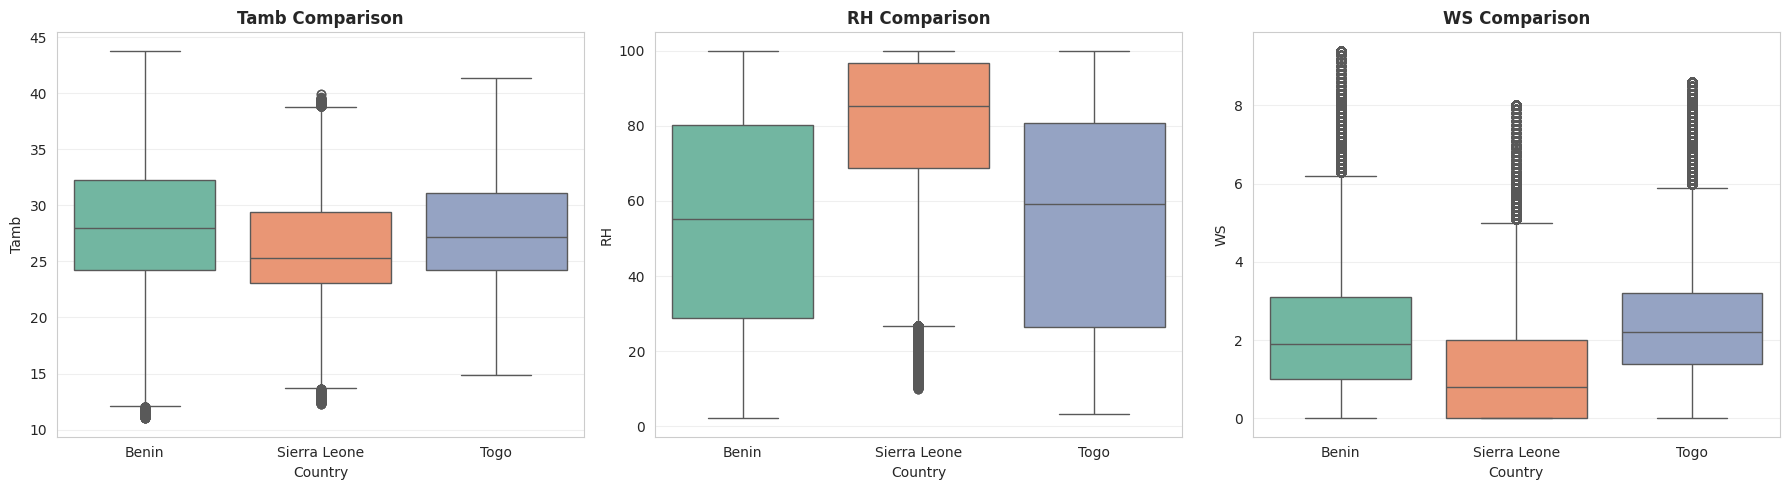

ENVIRONMENTAL CONDITIONS SUMMARY
               Tamb           RH           WS      
               mean   std   mean    std  mean   std
Country                                            
Benin         28.18  5.92  54.49  28.07  2.12  1.59
Sierra Leone  26.32  4.40  79.45  20.52  1.14  1.23
Togo          27.75  4.76  55.01  28.78  2.37  1.45




In [8]:
# Compare environmental conditions
env_metrics = ['Tamb', 'RH', 'WS']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(env_metrics):
    sns.boxplot(data=combined_df, x='Country', y=metric, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Country', fontsize=10)
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary of environmental conditions
print("=" * 80)
print("ENVIRONMENTAL CONDITIONS SUMMARY")
print("=" * 80)
env_summary = combined_df.groupby('Country')[['Tamb', 'RH', 'WS']].agg(['mean', 'std']).round(2)
print(env_summary)
print("\n")


## Summary and Recommendations

### Key Findings

1. **Solar Potential Ranking**: 
   - **#1 Benin**: 241.96 W/m² - **Highest solar potential, best for large-scale installations**
   - **#2 Togo**: 231.72 W/m² - **Strong second, but requires aggressive maintenance**
   - **#3 Sierra Leone**: 204.41 W/m² - **Lowest potential, faces environmental challenges**

2. **Statistical Significance**: 
   - **ANOVA p-value**: < 0.001 - **Highly significant differences** between countries
   - **Kruskal-Wallis p-value**: < 0.001 - **Highly significant differences** in distributions
   - The differences are **statistically significant** and meaningful for investment decisions

3. **System Type Recommendations**:
   - **Benin**: Best for **CSP and tracking systems** (DNI: 167.44 W/m² > DHI: 116.99 W/m²)
   - **Togo**: Good for **both fixed-tilt and tracking systems** (DNI: 151.26 W/m² > DHI: 116.44 W/m²)
   - **Sierra Leone**: Best for **fixed-tilt systems only** (DNI: 92.15 W/m² < DHI: 116.27 W/m²) - **NOT suitable for CSP**

4. **Environmental Factors**:
   - **Humidity**: Sierra Leone's high humidity (79.45%) is a major concern
   - **Temperature**: All countries have favorable temperatures (26-28°C)
   - **Wind**: Togo has highest wind speed (2.37 m/s), which may provide natural cleaning

5. **Maintenance Requirements**:
   - **Togo**: **Critical** - 136.8% cleaning impact requires aggressive maintenance schedules
   - **Sierra Leone**: **High** - 32.3% cleaning impact, plus high humidity accelerates soiling
   - **Benin**: **Moderate** - 29.9% cleaning impact, standard maintenance protocols

### Recommendations

1. **Investment Priority**:
   - **Primary Investment**: **Benin** - Highest GHI (241.96 W/m²), highest DNI (167.44 W/m²), favorable environmental conditions
   - **Secondary Investment**: **Togo** - Strong GHI (231.72 W/m²), but requires aggressive maintenance (136.8% cleaning impact)
   - **Tertiary Investment**: **Sierra Leone** - Lowest GHI (204.41 W/m²), high humidity, DNI < DHI (cloudy conditions)

2. **System Type Selection**: 
   - **Benin**: **CSP and tracking systems** recommended (highest DNI, clear sky conditions)
   - **Togo**: **Fixed-tilt and tracking systems** both viable (good DNI, moderate conditions)
   - **Sierra Leone**: **Fixed-tilt systems only** (DNI < DHI, cloudy conditions, NOT suitable for CSP)

3. **Maintenance Planning**: 
   - **Togo**: Implement **aggressive cleaning schedules** (monthly/bi-monthly) due to 136.8% cleaning impact
   - **Sierra Leone**: Implement **frequent cleaning** due to high humidity (79.45%) and 32.3% cleaning impact
   - **Benin**: Standard maintenance protocols (29.9% cleaning impact)

4. **Risk Assessment**: 
   - **Sierra Leone**: Highest risk due to low GHI, high humidity, and cloudy conditions (DNI < DHI)
   - **Togo**: Moderate risk due to extreme cleaning requirements (may indicate environmental challenges)
   - **Benin**: Lowest risk due to highest GHI, favorable conditions, and moderate maintenance needs

5. **Strategic Recommendations**:
   - **Large-scale CSP projects**: Focus on **Benin** (highest DNI: 167.44 W/m²)
   - **Standard solar installations**: **Benin** and **Togo** are both viable, with Benin preferred
   - **Fixed-tilt systems**: All countries are viable, but **Benin** and **Togo** are preferred
   - **Maintenance-intensive projects**: Consider **Benin** (lower maintenance requirements) or **Togo** (if maintenance infrastructure is available)

6. **Final Recommendation**:
   - **Benin** is the **clear winner** for solar investment with the highest potential, best environmental conditions, and moderate maintenance requirements
   - **Togo** shows strong potential but requires significant investment in maintenance infrastructure
   - **Sierra Leone** has lower potential and faces environmental challenges, making it less attractive for large-scale solar investments
